In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the Cancer Prediction dataset
df = pd.read_csv('Cancer_Prediction.csv')

# Clean columns (drops 'id' and empty columns caused by trailing commas in the CSV)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Features (X) and Target (y)
X = df.drop(columns=['id', 'diagnosis'], errors='ignore')  # Features
y = df['diagnosis']  # Labels ('M' for Malignant, 'B' for Benign)


In [3]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Initialize the KNN classifier with k=3
knn = KNeighborsClassifier(n_neighbors=3)

# Fit the model on training data
knn.fit(X_train, y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
# # Make predictions on the test set
# y_pred = knn.predict(X_test)
# print(y_pred)

# # Calculate accuracy
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Accuracy: {accuracy * 100:.2f}%')


['M' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B'
 'B' 'M' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'M' 'B' 'B' 'M'
 'B' 'B' 'M' 'B' 'B' 'M']
Accuracy: 92.98%


In [7]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.98%


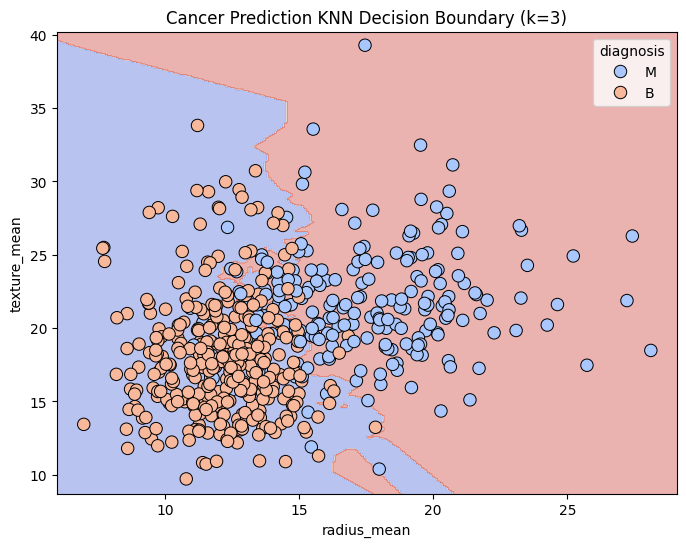

In [9]:
# Plot the decision boundary using radius_mean and texture_mean
def plot_knn(X, y, n_neighbors):
    # Extract the first two features (radius_mean and texture_mean)
    X_2d = X.iloc[:, :2].values if hasattr(X, 'iloc') else X[:, :2]
    feature_names = X.columns[:2] if hasattr(X, 'columns') else ['radius_mean', 'texture_mean']

    # Convert string labels ('M' / 'B') to 0 / 1 for contour plotting
    y_num = pd.Series(y).astype('category').cat.codes.values

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_2d, y_num)

    # Create a mesh grid for the decision boundary
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, 
                    palette='coolwarm', s=80, edgecolor='k')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f'Cancer Prediction KNN Decision Boundary (k={n_neighbors})')
    plt.show()

# Call the function with k=3
plot_knn(X, y, n_neighbors=3)


In [11]:
# Convert diagnosis to 1 (Malignant) and 0 (Benign)
df_corr = df.copy()
df_corr['diagnosis_num'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

# Get top 10 features most correlated with Cancer
correlations = df_corr.corr(numeric_only=True)['diagnosis_num'].abs().sort_values(ascending=False)
print("Top 10 Most Important Features:")
print(correlations[1:11])  # Exclude self-correlation


Top 10 Most Important Features:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis_num, dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv('spam_ham_dataset.csv')

# Categorization / Label Encoding: map string labels ('ham' -> 0, 'spam' -> 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Feature extraction using CountVectorizer on the message column
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label_num']

# Split data into training and testing sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Multinomial Naive Bayes Model
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Predict and Evaluate
y_pred = nb_classifier.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['Not Spam (Ham)', 'Spam']))


Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

Not Spam (Ham)       1.00      1.00      1.00        43
          Spam       1.00      1.00      1.00        37

      accuracy                           1.00        80
     macro avg       1.00      1.00      1.00        80
  weighted avg       1.00      1.00      1.00        80



--- Top 10 Most Predictive Features ---
 1. concave points_worst      (Correlation: 0.7936)
 2. perimeter_worst           (Correlation: 0.7829)
 3. concave points_mean       (Correlation: 0.7766)
 4. radius_worst              (Correlation: 0.7765)
 5. perimeter_mean            (Correlation: 0.7426)
 6. area_worst                (Correlation: 0.7338)
 7. radius_mean               (Correlation: 0.7300)
 8. area_mean                 (Correlation: 0.7090)
 9. concavity_mean            (Correlation: 0.6964)
10. concavity_worst           (Correlation: 0.6596)

--- KNN Accuracy vs Number of Features ---
 Top N Features  Accuracy (%)
              1         88.60
              2         92.11
              3         92.98
              5         94.74
              8         92.98
             10         92.98
             15         92.98
             20         92.98
             30         92.98


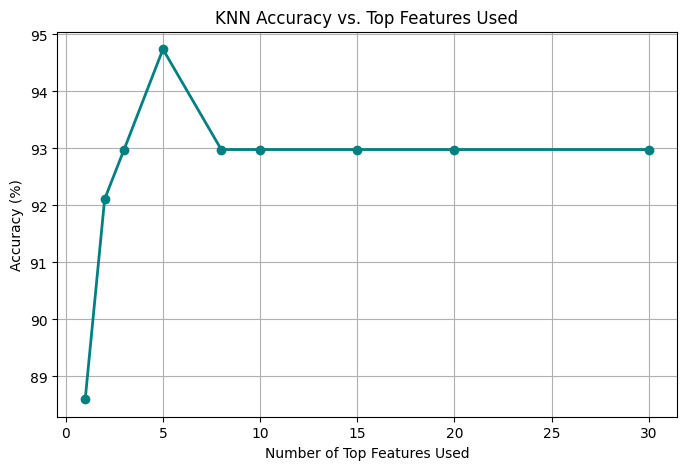

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Load data & clean
df = pd.read_csv('Cancer_Prediction.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop 'id' immediately so it is never ranked as a feature
df = df.drop(columns=['id'], errors='ignore')

# Convert target to numeric for correlation calculation
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})
X_all = df.drop(columns=['diagnosis', 'diagnosis_num'], errors='ignore')
y = df['diagnosis']

# 2. Rank features by correlation strength
correlations = df.corr(numeric_only=True)['diagnosis_num'].abs()
ranked_features = correlations.drop('diagnosis_num').sort_values(ascending=False).index.tolist()

print("--- Top 10 Most Predictive Features ---")
for rank, feat in enumerate(ranked_features[:10], 1):
    print(f"{rank:2d}. {feat:<25} (Correlation: {correlations[feat]:.4f})")

# 3. Test KNN accuracy across different numbers of top features
top_counts = [1, 2, 3, 5, 8, 10, 15, 20, len(ranked_features)]
accuracy_results = []

for n in top_counts:
    selected_features = ranked_features[:n]
    X_subset = X_all[selected_features]
    
    # Split data (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42)
    
    # Train KNN (k=3)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results.append({'Top N Features': n, 'Accuracy (%)': round(acc, 2)})

# 4. Display Summary Table
results_df = pd.DataFrame(accuracy_results)
print("\n--- KNN Accuracy vs Number of Features ---")
print(results_df.to_string(index=False))

# 5. Plot Accuracy vs Feature Count
plt.figure(figsize=(8, 5))
plt.plot(results_df['Top N Features'], results_df['Accuracy (%)'], marker='o', linewidth=2, color='teal')
plt.xlabel('Number of Top Features Used')
plt.ylabel('Accuracy (%)')
plt.title('KNN Accuracy vs. Top Features Used')
plt.grid(True)
plt.show()


Top 5 Features Used:
1. concave points_worst
2. perimeter_worst
3. concave points_mean
4. radius_worst
5. perimeter_mean


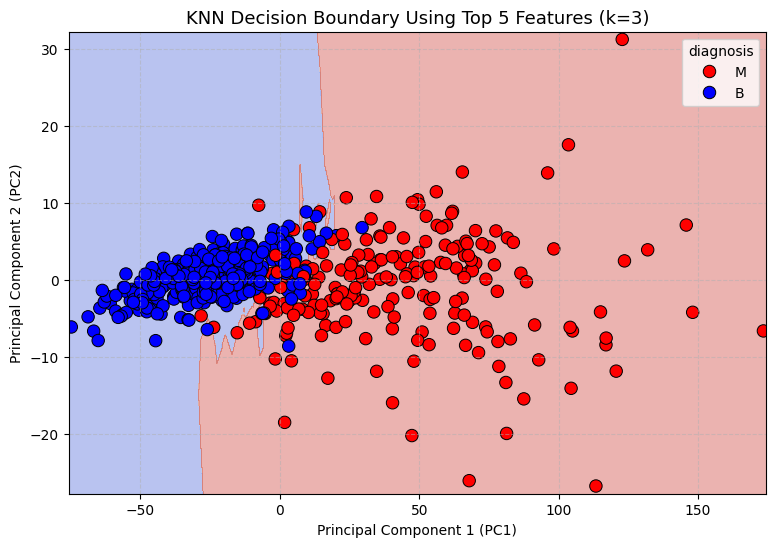

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# 1. Load & Clean Dataset
df = pd.read_csv('Cancer_Prediction.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.drop(columns=['id'], errors='ignore')

# 2. Get Top 5 Features by Correlation
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})
correlations = df.corr(numeric_only=True)['diagnosis_num'].abs()
top_5_features = correlations.drop('diagnosis_num').sort_values(ascending=False).index[:5].tolist()

print("Top 5 Features Used:")
for idx, feat in enumerate(top_5_features, 1):
    print(f"{idx}. {feat}")

# Extract Top 5 Features & Target
X_5 = df[top_5_features]
y = df['diagnosis']

# 3. Project Top 5 Features into 2D using PCA for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_5)

# Convert target labels to numeric for contour rendering
y_num = pd.Series(y).map({'M': 1, 'B': 0}).values

# 4. Train KNN Model (k=3) on the 2D projection
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_pca, y_num)

# 5. Create mesh grid for decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 6. Plot the Decision Boundary Graph
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, 
                palette={'M': 'red', 'B': 'blue'}, s=80, edgecolor='k')

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('KNN Decision Boundary Using Top 5 Features (k=3)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Top 5 Features Used:
1. concave points_worst
2. perimeter_worst
3. concave points_mean
4. radius_worst
5. perimeter_mean


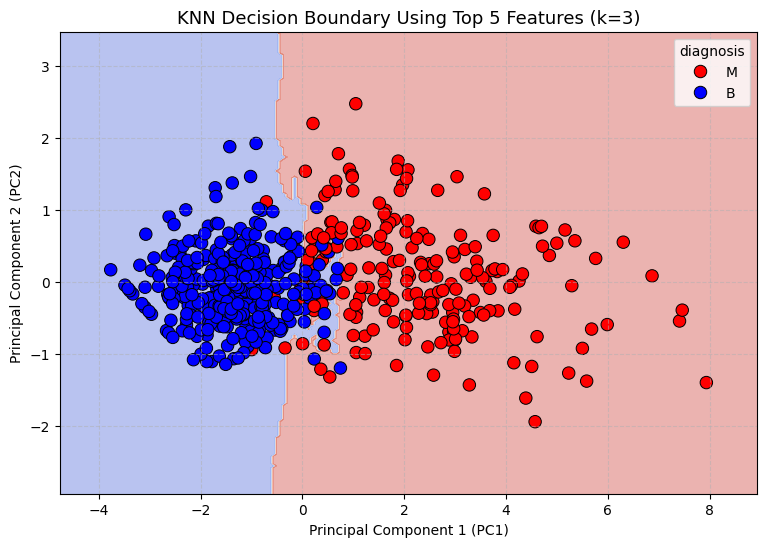

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load & Clean Dataset
df = pd.read_csv('Cancer_Prediction.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.drop(columns=['id'], errors='ignore')

# 2. Get Top 5 Features by Correlation
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})
correlations = df.corr(numeric_only=True)['diagnosis_num'].abs()
top_5_features = correlations.drop('diagnosis_num').sort_values(ascending=False).index[:5].tolist()

print("Top 5 Features Used:")
for idx, feat in enumerate(top_5_features, 1):
    print(f"{idx}. {feat}")

# Extract Top 5 Features & Target
X_5 = df[top_5_features]
y = df['diagnosis']

# 3. Scale Features (Prevents huge PCA range) & Project to 2D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_5)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert target labels to numeric
y_num = pd.Series(y).map({'M': 1, 'B': 0}).values

# 4. Train KNN Model (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_pca, y_num)

# 5. Create Lightweight Grid (Exactly 200x200 = 40,000 points)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 6. Fast Plot Rendering
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, 
                palette={'M': 'red', 'B': 'blue'}, s=80, edgecolor='k')

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('KNN Decision Boundary Using Top 5 Features (k=3)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [43]:
data = {
    'BRIGHTNESS': [40, 50, 60, 10, 70, 60, 25],
    'SATURATION': [20, 50, 90, 25, 70, 10, 80],
    'CLASS': ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}

df = pd.DataFrame(data)


In [45]:
df

,BRIGHTNESS,SATURATION,CLASS
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [47]:
X = df[['BRIGHTNESS', 'SATURATION']]
y = df['CLASS']


In [49]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [61]:
new_data = [[20, 35]]
predicted_class_1 = knn.predict(new_data)
predicted_class_1


C:\Users\Nishanth\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Apple'], dtype=object)

In [63]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Step 2: Create the dataset
data = {
    'Weight': [150, 170, 140, 130, 180, 160, 155, 165],
    'Color_Intensity': [7, 6, 8, 6, 5, 8, 7, 5],
    'Label': ['Apple', 'Apple', 'Apple', 'Apple', 'Orange', 'Orange', 'Orange', 'Orange']
}

df = pd.DataFrame(data)

# Step 3: Split the data into features (X) and labels (y)
X = df[['Weight', 'Color_Intensity']]
y = df['Label']

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Initialize the KNN classifier (k=3) and train it
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 6: Predict the label of a new fruit with weight 150 and color intensity 6
new_data = [[150, 6]]
predicted_label = knn.predict(new_data)

print(f"The predicted label for weight 150 and color intensity 6 is: {predicted_label[0]}")

# Optional: Evaluate the accuracy of the classifier on the test set
accuracy = knn.score(X_test, y_test)
print(f"The accuracy of the KNN classifier is: {accuracy * 100:.2f}%")


The predicted label for weight 150 and color intensity 6 is: Orange
The accuracy of the KNN classifier is: 33.33%


C:\Users\Nishanth\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [65]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the KNN classifier with weights
k = 3
knn = KNeighborsClassifier(n_neighbors=k, weights='distance')  # Using distance weighting
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of weighted KNN: {accuracy:.2f}")


Accuracy of weighted KNN: 1.00


In [67]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [69]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [79]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [83]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()

# Create a DataFrame to display the categories
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display the first few rows to show the categories of iris
print(df_iris.tail())


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target    species  
145       2  virginica  
146       2  virginica  
147       2  virginica  
148       2  virginica  
149       2  virginica  


In [1]:
import pandas as pd
from sklearn.datasets import load_boston

# Load the dataset
boston_data = load_boston()

# Create a DataFrame
boston_df = pd.DataFrame(data=boston_data.data, columns=boston_data.feature_names)

# Add the target variable to the DataFrame
boston_df['MEDV'] = boston_data.target

# Display the first few rows of the DataFrame
print(boston_df.head())


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

Alternative datasets include the California housing dataset and the
Ames housing dataset. You can load the datasets as follows::

    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()

for the California housing dataset and::

    from sklearn.datasets import fetch_openml
    housing = fetch_openml(name="house_prices", as_frame=True)

for the Ames housing dataset.

[1] M Carlisle.
"Racist data destruction?"
<https://medium.com/@docintangible/racist-data-destruction-113e3eff54a8>

[2] Harrison Jr, David, and Daniel L. Rubinfeld.
"Hedonic housing prices and the demand for clean air."
Journal of environmental economics and management 5.1 (1978): 81-102.
<https://www.researchgate.net/publication/4974606_Hedonic_housing_prices_and_the_demand_for_clean_air>


In [3]:
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
california_data = fetch_california_housing()

# Create a DataFrame
california_df = pd.DataFrame(data=california_data.data, columns=california_data.feature_names)
california_df['MedHouseVal'] = california_data.target

# Display the first few rows
print(california_df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
